In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestRegressor
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import statsmodels.api as sm
from statsmodels.formula.api import ols

# 设置中文字体
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

In [7]:
# 读取数据
data = pd.read_excel('数据汇总A.xlsx')
conditions = pd.read_excel('实验条件A.xlsx')
data.head(100)

,序号,尺寸nm
0,1,4.20
1,1,6.20
2,1,8.10
3,1,9.70
4,1,11.30
5,1,15.00
6,3,4.22
7,3,5.41
8,3,6.49
9,3,7.52


In [8]:
# 显示实验条件的前100行。
conditions.head(100)

,试验号,注入温度,生长温度,反应时间,Hg源,Hg源质量,Hg源摩尔数,Te源,Te粉质量,Te粉摩尔数,...,胺类,体积,羧酸类,体积.1,膦类,体积.2,硫醇类,体积.3,其他类,体积.4
0,1,100,80,4,HgCl2,0.081456,0.30,TOPTe,1.276,10.000,...,OAM,5,OA,0.5,无,0.00,DDT,23.0,β-ME,0.14
1,3,110,110,2,HgCl2,0.0543,0.20,TOPTe,2.540,20.000,...,OAM,15.6,无,0.0,TOP,0.10,DDT,2.0,无,0.00
2,14,90,90,3,HgCl2,0.054,0.20,TOPTe,0.128,1.003,...,OAM,13,无,0.0,TOP,0.10,DDT,1.0,无,0.00
3,18,25,60,10,Hg(OAc)2,0.07927,0.25,TOPTe,1.276,10.000,...,OAM,0.5 mmol（191 mg）,无,0.0,无,0.00,DDT,NaN,无,0.00
4,26,300,300,3,HgCl2,0.054,0.20,TOPTe,5.080,40.000,...,OAM,18,无,0.0,TOPTe,0.20,DDT,1.0,无,0.00
5,163,80,80,90,HgBr₂,0.108,0.30,TOPTe,1.276,0.300,...,OAM,10,无,0.0,TOP,0.32,DDT,1.0,DDAB,0.50


In [9]:
# 数据预处理
# 填充序号列的NaN值
data['序号'] = data['序号'].fillna(method='ffill')

# 删除基布数据
base_fabric = data[data['序号'] == '基布']
data = data[data['序号'] != '基布']
data.head(16)

# 将性能指标列转换为数值类型
performance = ['尺寸nm']
for col in performance:
    data[col] = pd.to_numeric(data[col], errors='coerce')

# 计算同一个group内部的平均值
data_mean = data.groupby('序号').mean().reset_index()


# 数据清洗：删除不需要的列
columns_to_drop = ['Hg源', 'Te源', '胺类', '体积', '羧酸类', '体积.1', '膦类', '体积.2', '硫醇类', '体积.3', '其他类', '体积.4']
conditions = conditions.drop(columns=columns_to_drop, errors='ignore')
# conditions['因素1（树脂含量）'] = conditions['因素1（树脂含量）'].str.rstrip('wt%').astype(float)
# conditions['因素2（固化温度）'] = conditions['因素2（固化温度）'].str.rstrip('℃').astype(float)

# 合并数据
merged_data = pd.merge(data_mean, conditions, left_on='序号', right_on='试验号')

# 标准化数据
scaler = StandardScaler()
features = ['注入温度', '生长温度', 'Hg源质量', '反应时间', 'Hg源摩尔数', 'Te粉质量', 'Te粉摩尔数', 'TOP体积', '前驱体体积', 'Hg:Te']
performance = ['尺寸nm']
scaled_data = pd.DataFrame(scaler.fit_transform(merged_data[features + performance]), columns=features + performance)


自变量X的描述性统计：
             注入温度        生长温度       反应时间    Hg源摩尔数     Te粉质量     Te粉摩尔数  \
count    6.000000    6.000000   6.000000  6.000000  6.000000   6.000000   
mean   117.500000  120.000000  18.666667  0.241667  1.929333  13.550500   
std     94.220486   89.666047  35.063751  0.049160  1.721915  14.828349   
min     25.000000   60.000000   2.000000  0.200000  0.128000   0.300000   
25%     82.500000   80.000000   3.000000  0.200000  1.276000   3.252250   
50%     95.000000   85.000000   3.500000  0.225000  1.276000  10.000000   
75%    107.500000  105.000000   8.500000  0.287500  2.224000  17.500000   
max    300.000000  300.000000  90.000000  0.300000  5.080000  40.000000   

           TOP体积     前驱体体积     Hg:Te  
count   6.000000  6.000000  6.000000  
mean   15.166667  0.166667  1.418833  
std    13.570802  0.081650  0.849077  
min     1.000000  0.100000  0.030000  
25%    10.000000  0.100000  1.125000  
50%    10.000000  0.150000  1.500000  
75%    17.500000  0.200000  1.862250  

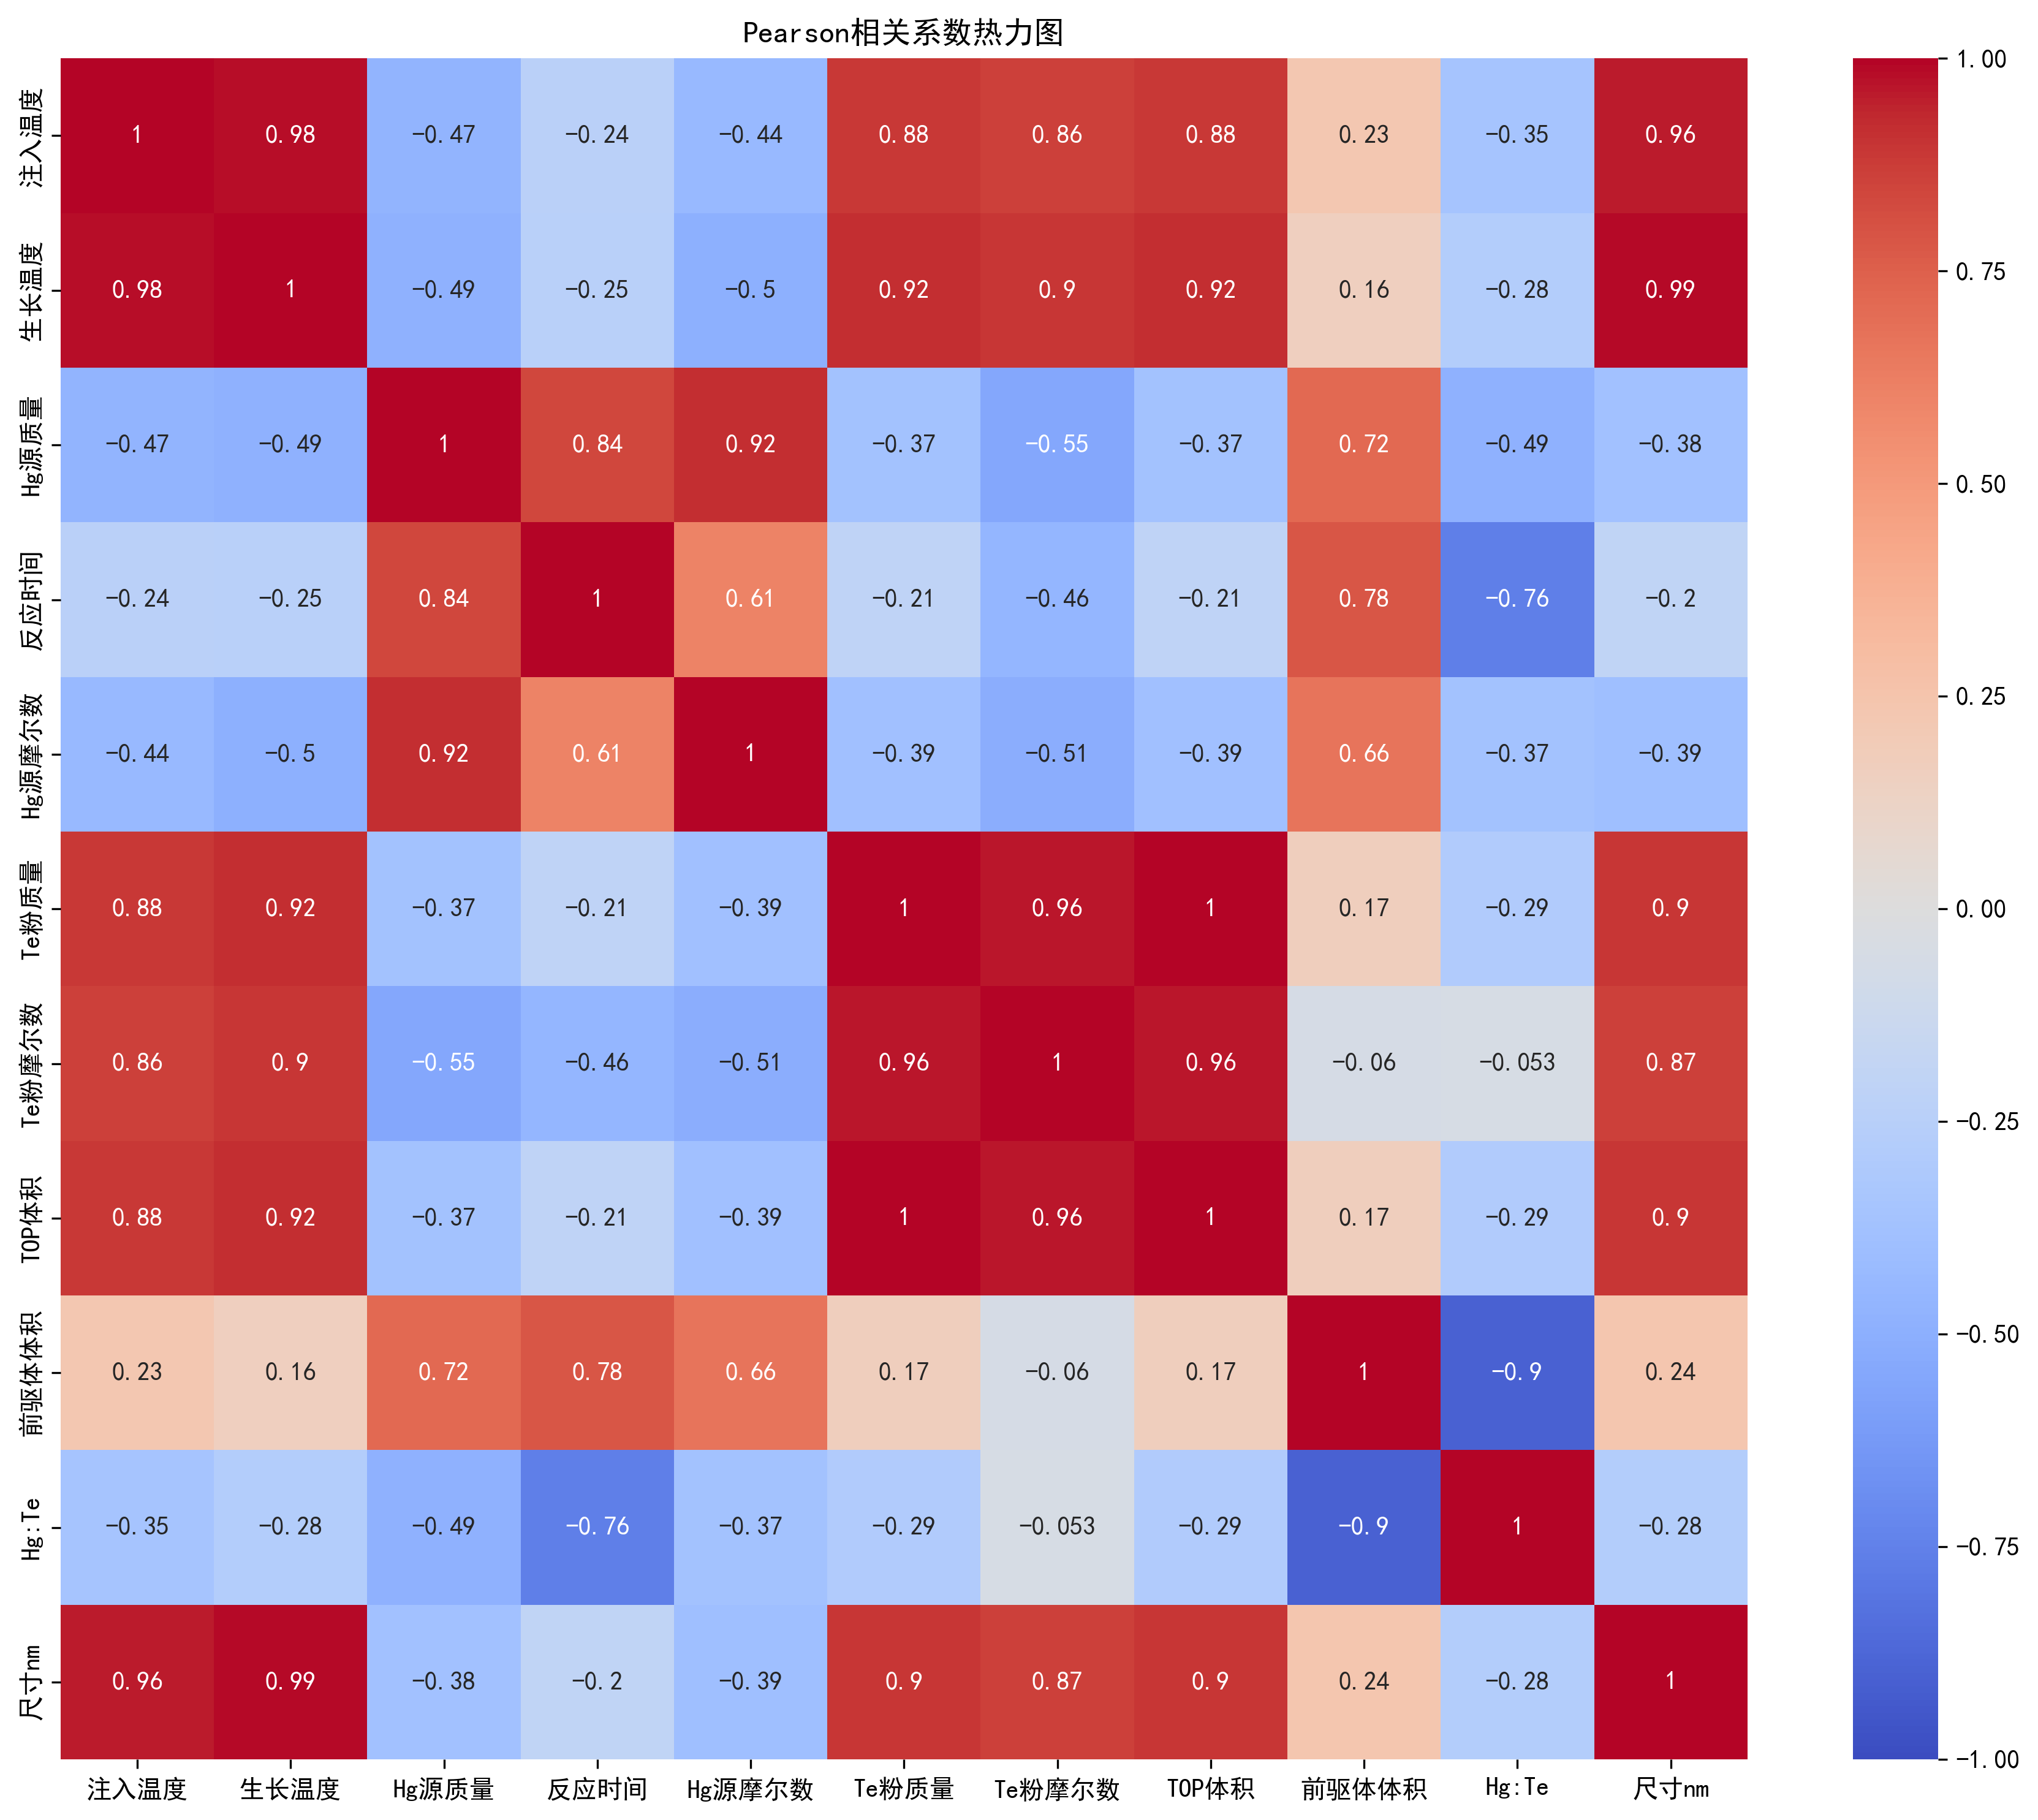

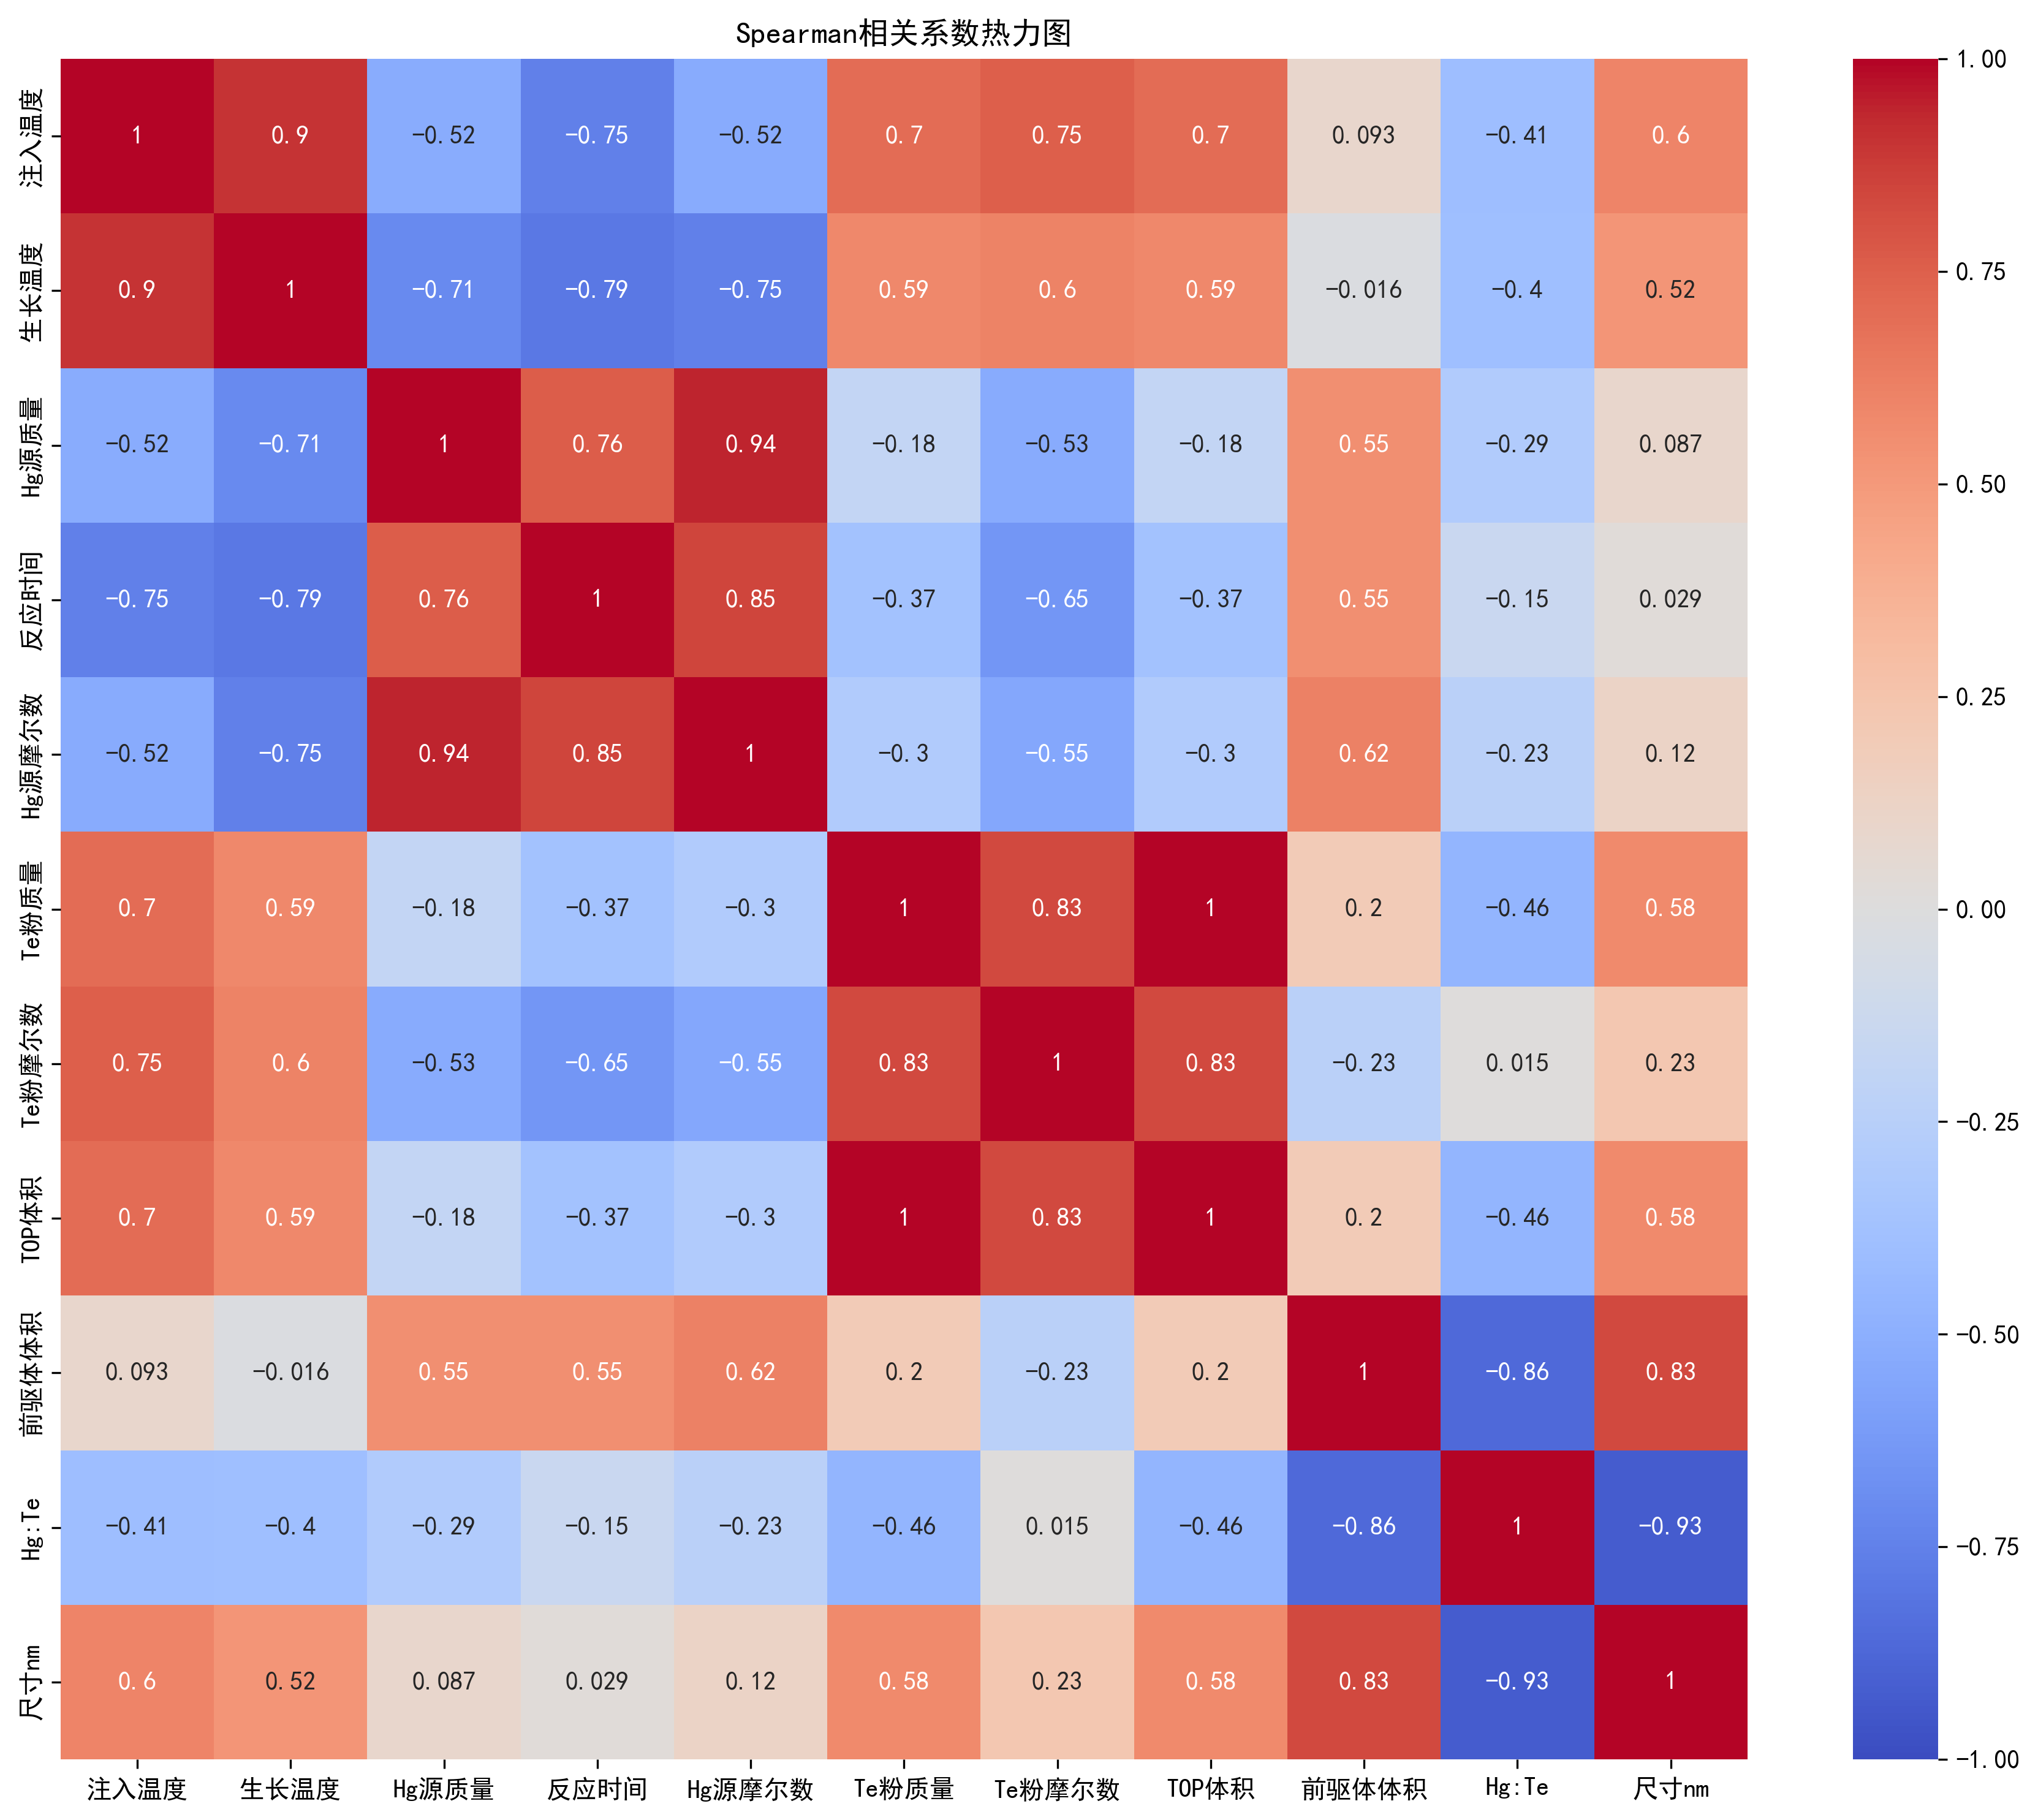


主成分分析解释方差比：
[1.]


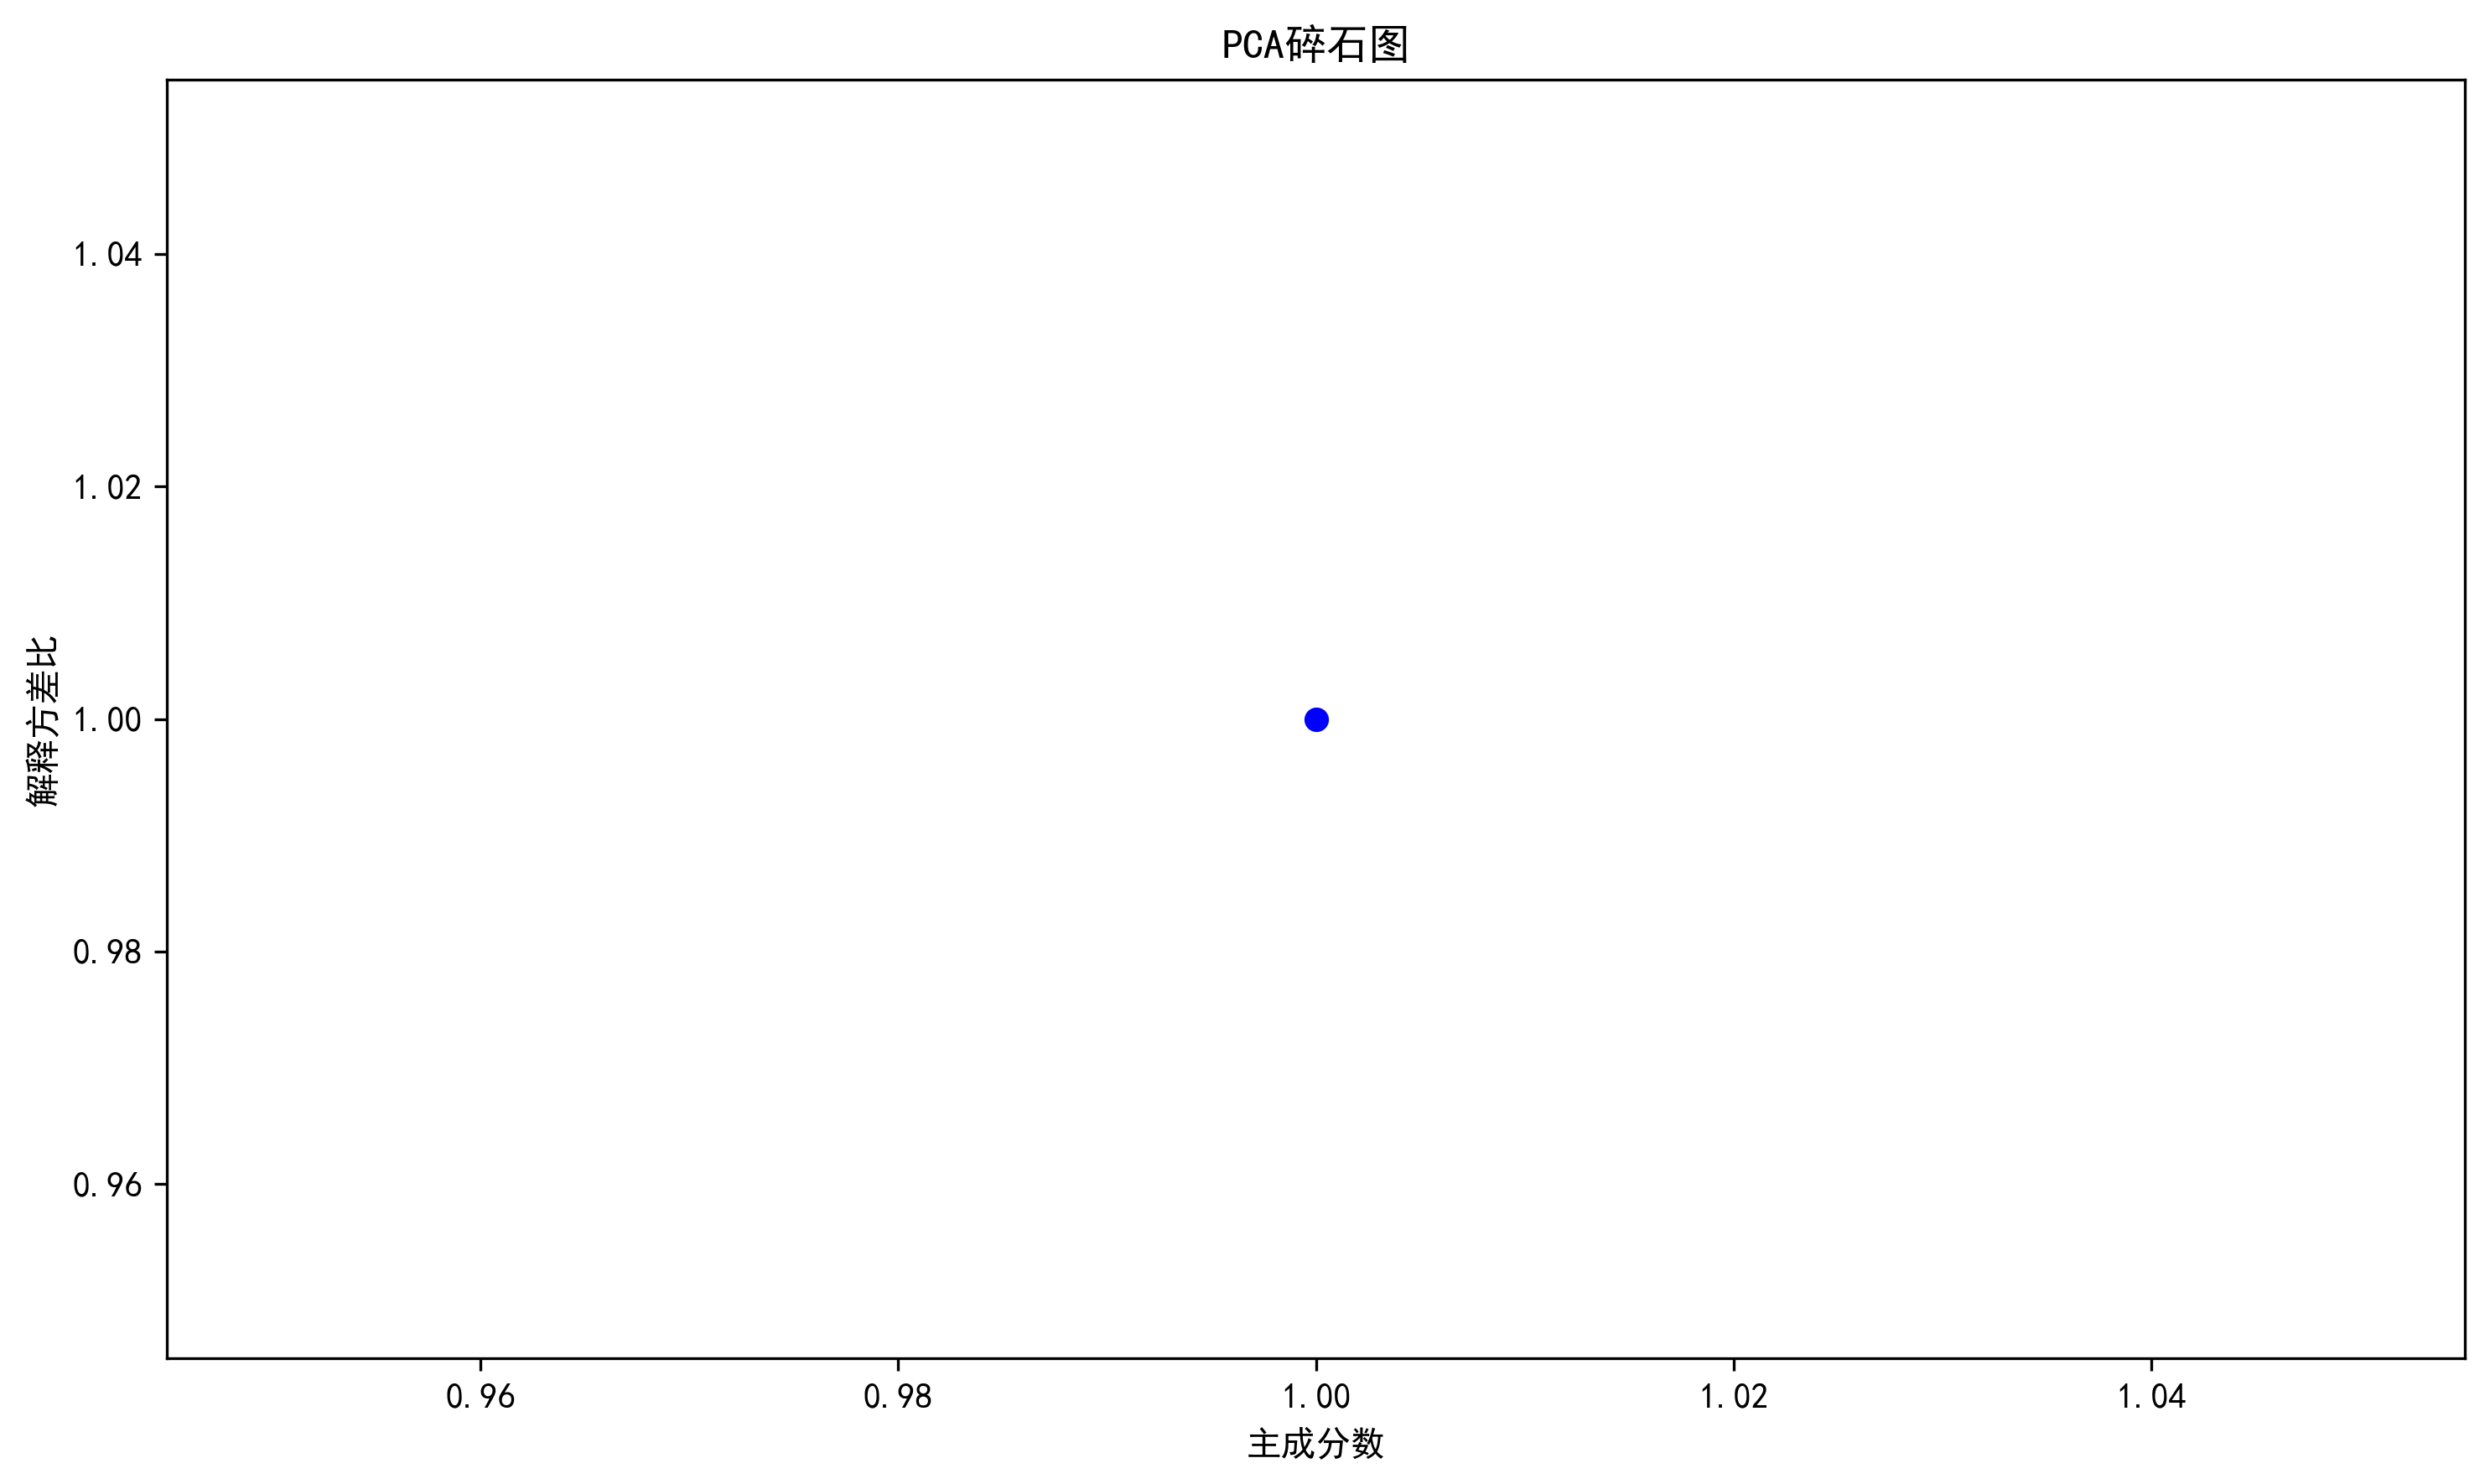


尺寸nm的特征重要性：
注入温度      0.187567
生长温度      0.155006
Hg源质量     0.094160
反应时间      0.082397
Hg源摩尔数    0.008630
Te粉质量     0.093038
Te粉摩尔数    0.117666
TOP体积     0.109868
前驱体体积     0.023454
Hg:Te     0.128213
dtype: float64


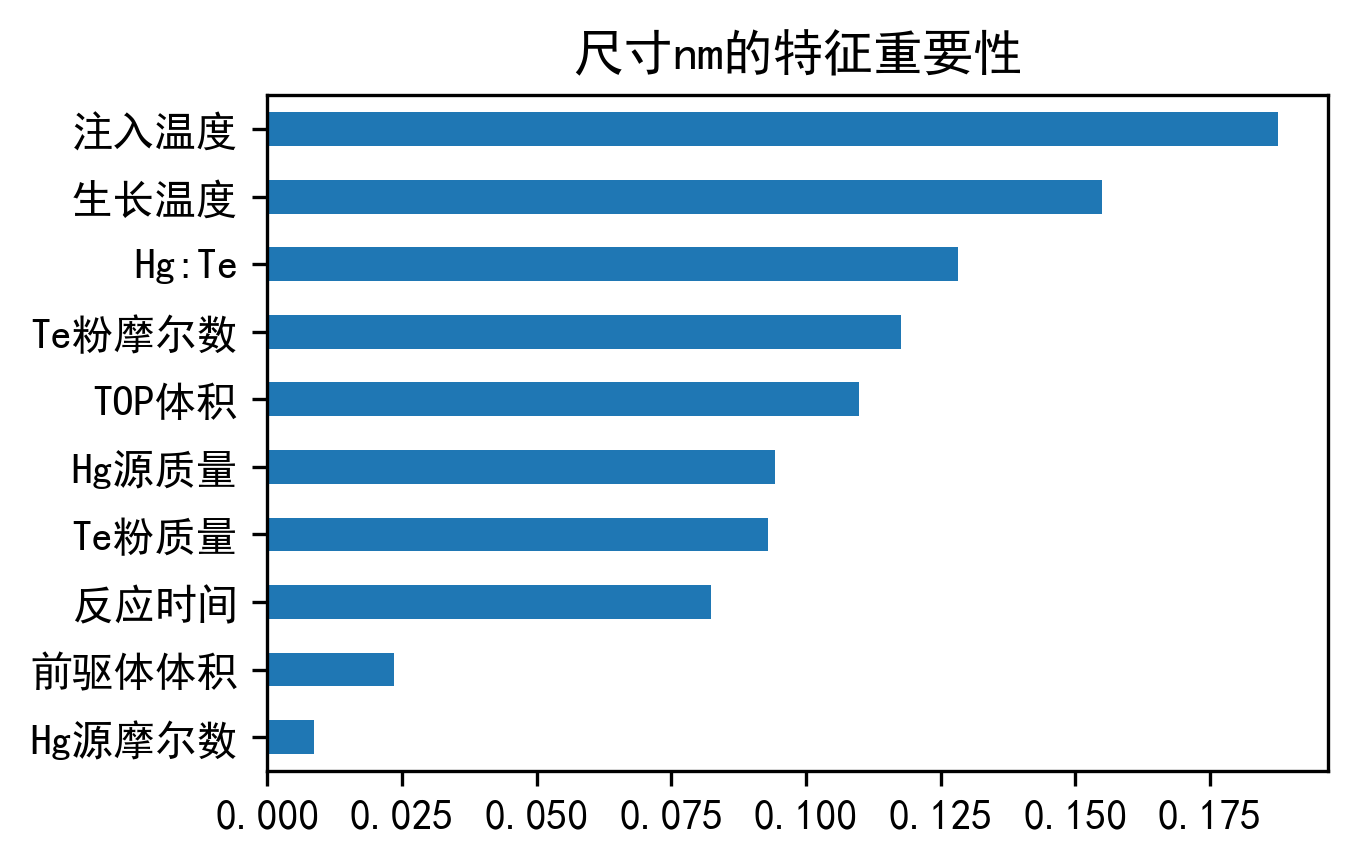

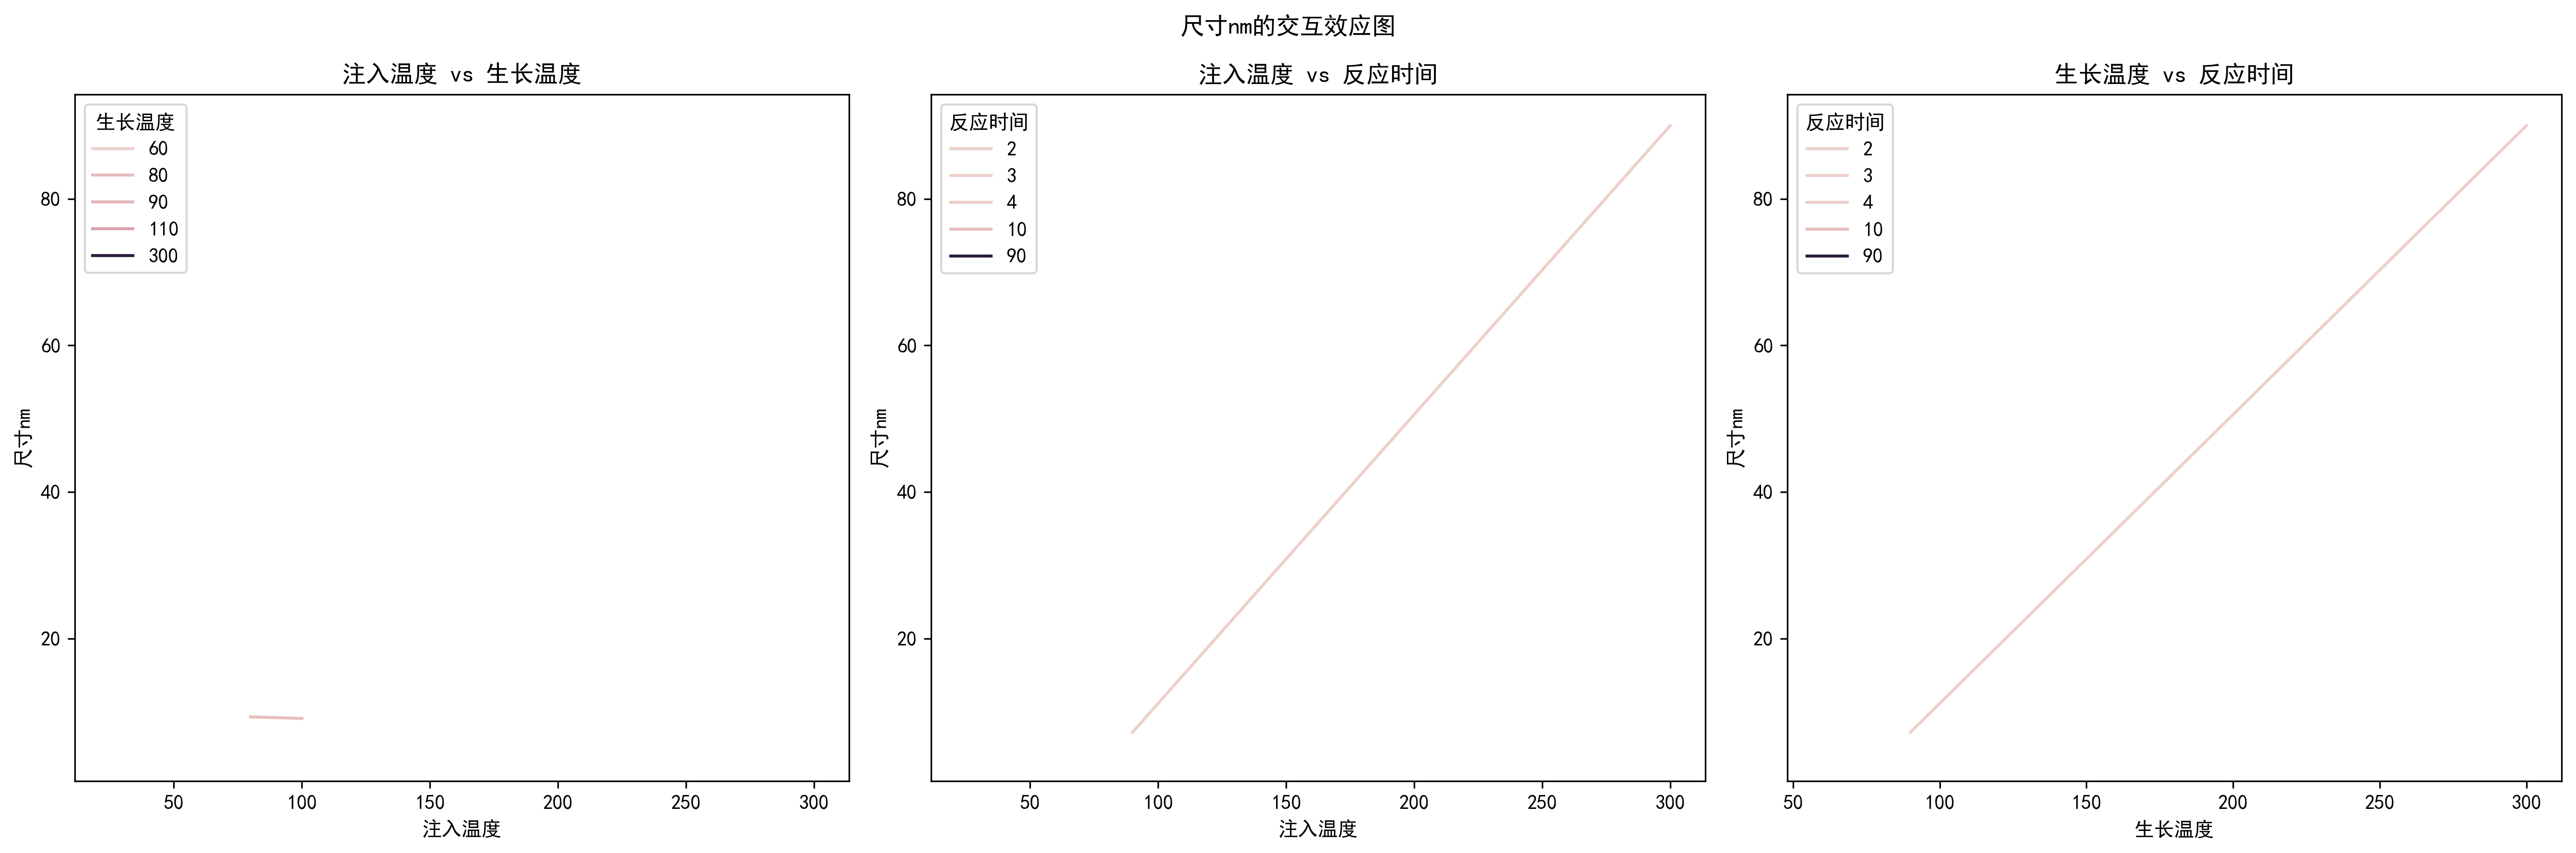

分析完成，所有图表和结果已保存。


In [10]:
features = ['注入温度', '生长温度', 'Hg源质量', '反应时间', 'Hg源摩尔数', 'Te粉质量', 'Te粉摩尔数', 'TOP体积', '前驱体体积', 'Hg:Te']
X = merged_data[features]
y = merged_data[performance]

print("\n自变量X的描述性统计：")
print(X.describe())

print("\n因变量y的描述性统计：")
print(y.describe())

# 标准化数据
scaler = StandardScaler()
scaled_data = pd.DataFrame(scaler.fit_transform(merged_data[features + performance]), columns=features + performance)

print("\n标准化后的数据前5行：")
print(scaled_data.head())

# 1. 相关性分析
corr_pearson = scaled_data.corr(method='pearson')
corr_spearman = scaled_data.corr(method='spearman')

print("\nPearson相关系数：")
print(corr_pearson)

print("\nSpearman相关系数：")
print(corr_spearman)

# 绘制相关性热力图
plt.figure(figsize=(12, 10), dpi=300)
sns.heatmap(corr_pearson, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Pearson相关系数热力图')
plt.tight_layout()
plt.savefig('问题1_Pearson相关系数热力图.png', dpi=300)
plt.show()

plt.figure(figsize=(12, 10), dpi=300)
sns.heatmap(corr_spearman, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Spearman相关系数热力图')
plt.tight_layout()
plt.savefig('问题1_Spearman相关系数热力图.png', dpi=300)
plt.show()

# 3. 主成分分析
pca = PCA()
pca_result = pca.fit_transform(scaled_data[performance])

print("\n主成分分析解释方差比：")
print(pca.explained_variance_ratio_)

# 绘制碎石图
plt.figure(figsize=(10, 6), dpi=300)
plt.plot(range(1, len(pca.explained_variance_ratio_) + 1), pca.explained_variance_ratio_, 'bo-')
plt.xlabel('主成分数')
plt.ylabel('解释方差比')
plt.title('PCA碎石图')
plt.tight_layout()
plt.savefig('问题1_PCA碎石图.png', dpi=300)
plt.show()

# 绘制前两个主成分的散点图 注意：数据汇总A只提供了一个主成分（尺寸nm），无法分析
# plt.figure(figsize=(10, 8), dpi=300)
# scatter = plt.scatter(pca_result[:, 0], pca_result[:, 1], c=merged_data['注入温度'], cmap='viridis')
# plt.colorbar(scatter, label='注入温度')
# plt.xlabel('第一主成分')
# plt.ylabel('第二主成分')
# plt.title('PCA散点图')
# plt.tight_layout()
# plt.savefig('问题1_PCA散点图.png', dpi=300)
# plt.show()

# 4. 随机森林特征重要性分析
rf_importances = {}
for metric in performance:
    rf = RandomForestRegressor(n_estimators=100, random_state=42)
    rf.fit(merged_data[features], merged_data[metric])
    importances = pd.Series(rf.feature_importances_, index=features)
    rf_importances[metric] = importances
    
    print(f"\n{metric}的特征重要性：")
    print(importances)

# 绘制特征重要性条形图
plt.figure(figsize=(12, 8), dpi=300)
for i, (metric, importances) in enumerate(rf_importances.items()):
    plt.subplot(3, 3, i+1)
    importances.sort_values().plot(kind='barh')
    plt.title(f'{metric}的特征重要性')
plt.tight_layout()
plt.savefig('问题1_随机森林特征重要性.png', dpi=300)
plt.show()

# 5. 交互效应可视化 ！！！！因为你的实验条件太多了，我这里仅展示：注入温度，生长温度，反应时间
for metric in performance:
    fig, axes = plt.subplots(1, 3, figsize=(18, 6), dpi=300)
    fig.suptitle(f'{metric}的交互效应图')
    
    sns.lineplot(data=merged_data, x='注入温度', y=metric, hue='生长温度', ax=axes[0])
    axes[0].set_title('注入温度 vs 生长温度')
    
    sns.lineplot(data=merged_data, x='注入温度', y=metric, hue='反应时间', ax=axes[1])
    axes[1].set_title('注入温度 vs 反应时间')
    
    sns.lineplot(data=merged_data, x='生长温度', y=metric, hue='反应时间', ax=axes[2])
    axes[2].set_title('生长温度 vs 反应时间')
    
    plt.tight_layout()
    plt.savefig(f'问题1_{metric}交互效应图.png', dpi=300)
    plt.show()
# print('原创作者：B站北辰single，禁止倒卖发现即起诉，原创地址https://www.yuque.com/u42168770/qv6z0d/qh4iwynq2co2gy3c')
print("分析完成，所有图表和结果已保存。")

In [11]:
"""
注意：这段代码不能计算，因为你未提供基布数据
"""
# print(base_fabric)
# print([merged_data['注入温度'].tolist(), [base_fabric['注入温度'].tolist()]])
# print(merged_data[metric].tolist().append([base_fabric[metric].tolist()]))
# # 6. 实验组数据与基布数据的可视化对比
# # 6. 实验组数据与基布数据的可视化对比
# plt.figure(figsize=(15, 10), dpi=300)
# for i, metric in enumerate(performance):
#     plt.subplot(3, 3, i+1)
#     # 绘制实验组的箱线图
#     bp1 = plt.boxplot(merged_data[metric].tolist(), positions=[1], widths=0.6)
    
#     # 绘制基布的箱线图（实际上是一个点）
#     bp2 = plt.boxplot([base_fabric[metric]], positions=[2], widths=0.6)
    
#     plt.title(f'{metric}对比')
#     plt.ylabel('数值')
#     plt.xticks([1, 2], ['实验组', '基布'])
    
# plt.tight_layout()
# plt.savefig('问题1_实验组与基布对比.png', dpi=300)
# plt.show()

'\n注意：这段代码不能计算，因为你未提供基布数据\n'